In [1]:
import json
import pandas as pd

# Percorso file matches Serie A 2015/16
matches_path = "open-data/data/matches/12/27.json"

with open(matches_path) as f:
    matches = json.load(f)

matches_df = pd.DataFrame(matches)

print("Numero partite:", len(matches_df))
matches_df.head()

Numero partite: 380


,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,metadata,match_week,competition_stage,stadium,referee
0,3879863,2016-05-08,15:00:00.000,"{'competition_id': 12, 'country_name': 'Italy'...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 228, 'home_team_name': 'Atala...","{'away_team_id': 230, 'away_team_name': 'Udine...",1,1,available,unscheduled,2023-07-24T07:00:20.863653,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",37,"{'id': 1, 'name': 'Regular Season'}","{'id': 4954, 'name': 'Gewiss Stadium', 'countr...","{'id': 419, 'name': 'Nicola Rizzoli', 'country..."
1,3879773,2016-03-06,16:00:00.000,"{'competition_id': 12, 'country_name': 'Italy'...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 291, 'home_team_name': 'Frosi...","{'away_team_id': 230, 'away_team_name': 'Udine...",2,0,available,unscheduled,2023-07-09T16:50:19.349248,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",28,"{'id': 1, 'name': 'Regular Season'}","{'id': 1001324, 'name': 'Stadio Comunale Matus...","{'id': 419, 'name': 'Nicola Rizzoli', 'country..."
2,3879847,2016-04-30,18:00:00.000,"{'competition_id': 12, 'country_name': 'Italy'...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 230, 'home_team_name': 'Udine...","{'away_team_id': 241, 'away_team_name': 'Torin...",1,5,available,unscheduled,2023-08-09T05:04:05.234384,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",36,"{'id': 1, 'name': 'Regular Season'}","{'id': 385, 'name': 'Dacia Arena', 'country': ...","{'id': 252, 'name': 'Maurizio Mariani', 'count..."
3,3879862,2016-05-08,20:45:00.000,"{'competition_id': 12, 'country_name': 'Italy'...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 241, 'home_team_name': 'Torin...","{'away_team_id': 227, 'away_team_name': 'Napol...",1,2,available,unscheduled,2023-07-24T07:01:17.104064,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",37,"{'id': 1, 'name': 'Regular Season'}","{'id': 390, 'name': 'Stadio Olimpico Grande To...","{'id': 266, 'name': 'Antonio Damato', 'country..."
4,3879817,2016-04-16,20:45:00.000,"{'competition_id': 12, 'country_name': 'Italy'...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 238, 'home_team_name': 'Inter...","{'away_team_id': 227, 'away_team_name': 'Napol...",2,0,available,unscheduled,2023-08-01T14:29:19.944772,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",33,"{'id': 1, 'name': 'Regular Season'}","{'id': 388, 'name': 'Stadio Giuseppe Meazza ...","{'id': 268, 'name': 'Gianluca Rocchi', 'countr..."


In [3]:
import os

# Percorso della cartella eventi (contiene un file JSON per ogni partita)
events_path = "open-data/data/events/"

# Lista dove accumuleremo tutti i tiri
all_shots = []

# Cicliamo su tutte le partite della stagione
for match_id in matches_df['match_id']:
    
    # Costruiamo il percorso del file eventi della partita
    file_path = os.path.join(events_path, f"{match_id}.json")
    
    # Apriamo il file JSON
    with open(file_path) as f:
        events = json.load(f)
    
    # Convertiamo la lista di eventi in DataFrame
    events_df = pd.DataFrame(events)
    
    # Filtriamo solo gli eventi di tipo "Shot"
    shots = events_df[events_df['type'].apply(lambda x: x['name'] == 'Shot')].copy()
    
    # Aggiungiamo match_id come colonna (utile per analisi future)
    shots['match_id'] = match_id
    
    # Aggiungiamo alla lista globale
    all_shots.append(shots)

# Uniamo tutti i tiri in un unico DataFrame
shots_df = pd.concat(all_shots, ignore_index=True)

print("Numero totale tiri nella stagione:", len(shots_df))

Numero totale tiri nella stagione: 9998


In [4]:
# Creiamo variabile target: 1 se gol, 0 altrimenti
shots_df['goal'] = shots_df['shot'].apply(
    lambda x: 1 if x['outcome']['name'] == 'Goal' else 0
)

# Controlliamo distribuzione
print("Numero goal:", shots_df['goal'].sum())
print("Percentuale goal:", shots_df['goal'].mean())

Numero goal: 951
Percentuale goal: 0.09511902380476095


In [5]:
# Estraiamo le coordinate del tiro (x, y)
shots_df[['x', 'y']] = shots_df['location'].apply(pd.Series)

# Verifichiamo
shots_df[['x', 'y']].head()

,x,y
0,112.0,35.7
1,96.1,19.5
2,110.3,41.2
3,108.1,40.1
4,110.5,23.4


In [6]:
import numpy as np

# Coordinate centro porta
GOAL_X = 120
GOAL_Y = 40

# Calcolo distanza euclidea
shots_df['distance'] = np.sqrt(
    (GOAL_X - shots_df['x'])**2 +
    (GOAL_Y - shots_df['y'])**2
)

shots_df[['distance']].head()

,distance
0,9.082401
1,31.487458
2,9.773945
3,11.900420
4,19.126160


In [11]:
# Larghezza porta in coordinate StatsBomb
GOAL_WIDTH = 8  # perché i pali sono tra y=36 e y=44 (44-36=8)

# Distanze rispetto al centro porta
dx = 120 - shots_df['x']
dy = shots_df['y'] - 40

# Calcolo angolo secondo formula stabile
shots_df['angle'] = np.arctan(
    (GOAL_WIDTH * dx) /
    (dx**2 + dy**2 - (GOAL_WIDTH / 2)**2)
)

# Valore assoluto (l'angolo deve essere positivo)
shots_df['angle'] = shots_df['angle'].abs()

shots_df['angle'].describe()

count    9998.000000
mean        0.413427
std         0.240704
min         0.000000
25%         0.253467
50%         0.321084
75%         0.496468
max         1.565588
Name: angle, dtype: float64

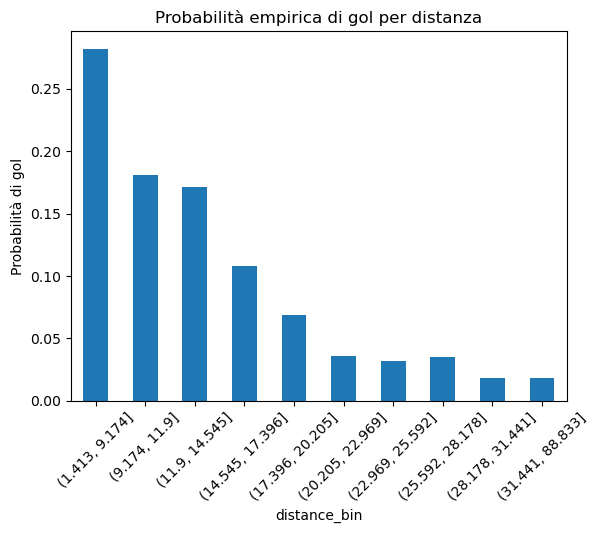

In [13]:
# Creiamo 10 gruppi (decili) di distanza
shots_df['distance_bin'] = pd.qcut(shots_df['distance'], q=10)

# Calcoliamo probabilità empirica di gol per ogni bin
distance_summary = shots_df.groupby('distance_bin')['goal'].mean()

distance_summary
import matplotlib.pyplot as plt

distance_summary.plot(kind='bar')
plt.title("Probabilità empirica di gol per distanza")
plt.ylabel("Probabilità di gol")
plt.xticks(rotation=45)
plt.show()

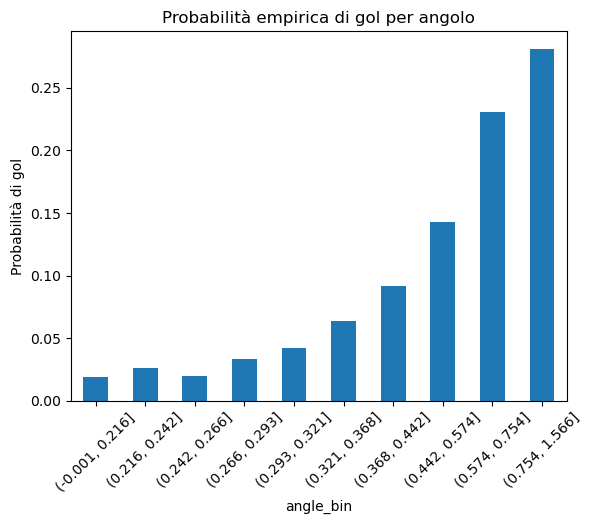

In [14]:
# Creiamo bin per angolo
shots_df['angle_bin'] = pd.qcut(shots_df['angle'], q=10)

# Probabilità empirica
angle_summary = shots_df.groupby('angle_bin')['goal'].mean()

angle_summary
angle_summary.plot(kind='bar')
plt.title("Probabilità empirica di gol per angolo")
plt.ylabel("Probabilità di gol")
plt.xticks(rotation=45)
plt.show()

In [15]:
# Controlliamo se esistono location mancanti
shots_df['location'].isna().sum()

0

In [16]:
shots_df['shot'].isna().sum()

0

In [17]:
# Tipo di shot
shots_df['shot'].apply(lambda x: x['type']['name']).value_counts()

shot
Open Play    9396
Free Kick     479
Penalty       121
Corner          2
Name: count, dtype: int64

In [18]:
# Separiamo rigori
penalties = shots_df[shots_df['shot'].apply(lambda x: x['type']['name'] == 'Penalty')]
non_penalties = shots_df[shots_df['shot'].apply(lambda x: x['type']['name'] != 'Penalty')]

print("Rigori:", len(penalties))
print("Altri tiri:", len(non_penalties))

Rigori: 121
Altri tiri: 9877


In [19]:
shots_df[(shots_df['x'] < 0) | (shots_df['x'] > 120)]
shots_df[(shots_df['y'] < 0) | (shots_df['y'] > 80)]

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,...,block,half_start,player_off,goal,x,y,distance,angle,distance_bin,angle_bin


In [22]:
(shots_df['distance'] >= 60).sum()

0

In [23]:
print("Numero totale righe:", len(shots_df))
print("\nColonne disponibili:")
print(shots_df.columns)

print("\nDistribuzione tipo di tiro:")
print(shots_df['shot'].apply(lambda x: x['type']['name']).value_counts())

print("\nDistance summary:")
print(shots_df['distance'].describe())

print("\nAngle summary:")
print(shots_df['angle'].describe())

Numero totale righe: 9981

Colonne disponibili:
Index(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'type',
       'possession', 'possession_team', 'play_pattern', 'team', 'duration',
       'tactics', 'related_events', 'player', 'position', 'location', 'pass',
       'carry', 'ball_receipt', 'under_pressure', 'foul_committed', 'foul_won',
       'out', 'dribble', 'counterpress', 'duel', 'interception', 'off_camera',
       'clearance', 'ball_recovery', 'shot', 'goalkeeper', 'substitution',
       '50_50', 'injury_stoppage', 'match_id', 'miscontrol', 'bad_behaviour',
       'block', 'half_start', 'player_off', 'goal', 'x', 'y', 'distance',
       'angle', 'distance_bin', 'angle_bin'],
      dtype='object')

Distribuzione tipo di tiro:
shot
Open Play    9380
Free Kick     478
Penalty       121
Corner          2
Name: count, dtype: int64

Distance summary:
count    9981.000000
mean       20.290433
std         8.579365
min         1.414214
25%        13.014607
50%        20.1

In [24]:
# Separiamo rigori
penalties = shots_df[shots_df['shot'].apply(lambda x: x['type']['name'] == 'Penalty')]

# Tiri non rigore
shots_df = shots_df[shots_df['shot'].apply(lambda x: x['type']['name'] != 'Penalty')]

print("Rigori separati:", len(penalties))
print("Tiri per modello xG:", len(shots_df))

Rigori separati: 121
Tiri per modello xG: 9860


In [25]:
X = shots_df[['distance', 'angle']]
y = shots_df['goal']
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Modello logistico
model = LogisticRegression()
model.fit(X_train, y_train)

# Probabilità predette (xG)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Metriche
roc = roc_auc_score(y_test, y_pred_proba)
brier = brier_score_loss(y_test, y_pred_proba)

print("ROC-AUC:", roc)
print("Brier score:", brier)

ROC-AUC: 0.7538302951388889
Brier score: 0.07527873934024824


In [26]:
# Intercetta
print("Intercept:", model.intercept_[0])

# Coefficienti
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
})

coef_df

Intercept: -1.6447903306026097


,feature,coefficient
0,distance,-0.081870
1,angle,1.361258


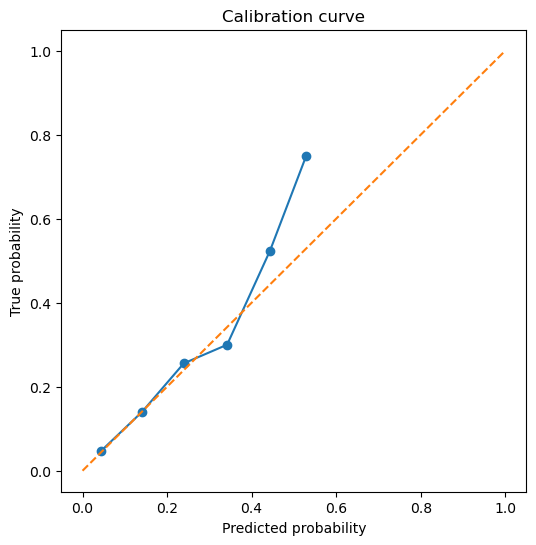

In [27]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_test,
    y_pred_proba,
    n_bins=10
)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title("Calibration curve")
plt.show()

In [28]:
# Estraiamo la parte del corpo
shots_df['body_part'] = shots_df['shot'].apply(
    lambda x: x['body_part']['name']
)

# Controlliamo distribuzione
shots_df['body_part'].value_counts()

/var/folders/wc/g2z8q9jx4717zwn9pdy03fph0000gn/T/ipykernel_50659/58611696.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shots_df['body_part'] = shots_df['shot'].apply(


body_part
Right Foot    5159
Left Foot     3258
Head          1420
Other           23
Name: count, dtype: int64

In [29]:
# Tipo di tiro (open play, free kick, corner, ecc.)
shots_df['shot_type'] = shots_df['shot'].apply(
    lambda x: x['type']['name']
)

shots_df['shot_type'].value_counts()

/var/folders/wc/g2z8q9jx4717zwn9pdy03fph0000gn/T/ipykernel_50659/1184357446.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shots_df['shot_type'] = shots_df['shot'].apply(


shot_type
Open Play    9380
Free Kick     478
Corner          2
Name: count, dtype: int64

In [30]:
# Convertiamo under_pressure in 0/1
shots_df['under_pressure'] = shots_df['under_pressure'].fillna(False).astype(int)

shots_df['under_pressure'].value_counts()

/var/folders/wc/g2z8q9jx4717zwn9pdy03fph0000gn/T/ipykernel_50659/3891879167.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shots_df['under_pressure'] = shots_df['under_pressure'].fillna(False).astype(int)


under_pressure
0    6667
1    3193
Name: count, dtype: int64

In [31]:
# Verifichiamo se esiste first_time
shots_df['first_time'] = shots_df['shot'].apply(
    lambda x: x.get('first_time', False)
).astype(int)

shots_df['first_time'].value_counts()

/var/folders/wc/g2z8q9jx4717zwn9pdy03fph0000gn/T/ipykernel_50659/830780436.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shots_df['first_time'] = shots_df['shot'].apply(


first_time
0    6747
1    3113
Name: count, dtype: int64

In [38]:
# Rimuoviamo corner (solo 2 osservazioni, instabile)
shots_df = shots_df[shots_df['shot_type'] != 'Corner']

# Verifichiamo distribuzione aggiornata
shots_df['shot_type'].value_counts()
# Feature numeriche
features = ['distance', 'angle', 'under_pressure', 'first_time']

# Categoriche
categorical = ['body_part', 'shot_type']

# One-hot encoding
shots_encoded = pd.get_dummies(
    shots_df[features + categorical],
    drop_first=True
)

# Target
y = shots_df['goal']

shots_encoded.head()

,distance,angle,under_pressure,first_time,body_part_Left Foot,body_part_Other,body_part_Right Foot,shot_type_Open Play
0,9.082401,0.766319,1,0,False,False,False,True
1,31.487458,0.193556,0,0,True,False,False,True
2,9.773945,0.773116,1,0,False,False,False,True
4,19.126160,0.213936,0,1,True,False,False,True
5,22.137976,0.252661,0,1,False,False,True,True


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss

X_train, X_test, y_train, y_test = train_test_split(
    shots_encoded, y, test_size=0.2, random_state=42
)

model_extended = LogisticRegression(max_iter=1000)
model_extended.fit(X_train, y_train)

y_pred_proba_ext = model_extended.predict_proba(X_test)[:,1]

roc_ext = roc_auc_score(y_test, y_pred_proba_ext)
brier_ext = brier_score_loss(y_test, y_pred_proba_ext)

print("ROC-AUC extended:", roc_ext)
print("Brier extended:", brier_ext)

ROC-AUC extended: 0.7680499819020191
Brier extended: 0.07291046698087315


In [40]:
coef_ext = pd.DataFrame({
    "feature": shots_encoded.columns,
    "coefficient": model_extended.coef_[0]
}).sort_values(by="coefficient", ascending=False)

coef_ext

,feature,coefficient
1,angle,1.857335
6,body_part_Right Foot,1.619363
4,body_part_Left Foot,1.414805
5,body_part_Other,0.393457
2,under_pressure,-0.101161
0,distance,-0.118841
3,first_time,-0.256243
7,shot_type_Open Play,-1.168897


In [41]:
shots_df['shot_type'].value_counts()
pd.get_dummies(
    shots_df[['shot_type']],
    drop_first=True
).columns

Index(['shot_type_Open Play'], dtype='object')

In [42]:
# Prendiamo match_id e match_week dal dataset partite
match_weeks = matches_df[['match_id', 'match_week']]

# Uniamo al dataset dei tiri
shots_df = shots_df.merge(match_weeks, on='match_id', how='left')

shots_df[['match_week']].head()
# Definiamo train e test temporali
train_df = shots_df[shots_df['match_week'] <= 30]
test_df  = shots_df[shots_df['match_week'] > 30]

print("Train shots:", len(train_df))
print("Test shots:", len(test_df))

Train shots: 7749
Test shots: 2109


In [43]:
# Feature numeriche
features = ['distance', 'angle', 'under_pressure', 'first_time']
categorical = ['body_part', 'shot_type']

# Train encoding
X_train = pd.get_dummies(
    train_df[features + categorical],
    drop_first=True
)

# Test encoding
X_test = pd.get_dummies(
    test_df[features + categorical],
    drop_first=True
)

# Allineiamo colonne (importantissimo)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train_df['goal']
y_test  = test_df['goal']

In [44]:
model_time = LogisticRegression(max_iter=1000)
model_time.fit(X_train, y_train)

y_pred_time = model_time.predict_proba(X_test)[:,1]

roc_time = roc_auc_score(y_test, y_pred_time)
brier_time = brier_score_loss(y_test, y_pred_time)

print("Time-based ROC-AUC:", roc_time)
print("Time-based Brier:", brier_time)

Time-based ROC-AUC: 0.7964919144496609
Time-based Brier: 0.07215364598481756


In [48]:
# Feature numeriche
features = ['distance', 'angle', 'under_pressure', 'first_time']
categorical = ['body_part', 'shot_type']

# Creiamo encoding su tutto il dataset
X_full = pd.get_dummies(
    shots_df[features + categorical],
    drop_first=True
)

# Allineiamo le colonne al modello (importantissimo)
X_full = X_full.reindex(columns=X_train.columns, fill_value=0)
shots_df['xG'] = model_time.predict_proba(X_full)[:,1]
shots_df[['xG', 'goal']].head()

,xG,goal
0,0.093666,1
1,0.013623,0
2,0.088276,0
3,0.042997,0
4,0.038578,0


In [50]:
shots_df['xG'].describe()
shots_df[['distance','angle','xG','goal']].head(10)

,distance,angle,xG,goal
0,9.082401,0.766319,0.093666,1
1,31.487458,0.193556,0.013623,0
2,9.773945,0.773116,0.088276,0
3,19.126160,0.213936,0.042997,0
4,22.137976,0.252661,0.038578,0
5,23.859799,0.227344,0.033665,0
6,16.552039,0.458097,0.100130,0
7,18.912959,0.416594,0.061575,0
8,30.257561,0.240705,0.013271,0
9,6.726812,1.071254,0.223920,0


In [55]:
shots_df['team_name'] = shots_df['team'].apply(lambda x: x['name'])
shots_df[['team_name']].head()
team_stats = shots_df.groupby('team_name').agg(
    shots=('xG', 'count'),
    total_xG=('xG', 'sum'),
    avg_xG_per_shot=('xG', 'mean'),
    goals=('goal', 'sum')
)

team_stats['xG_diff'] = team_stats['goals'] - team_stats['total_xG']

team_stats = team_stats.sort_values(by='avg_xG_per_shot', ascending=False)

team_stats.head()

,shots,total_xG,avg_xG_per_shot,goals,xG_diff
team_name,,,,,
Udinese,449,46.114476,0.102705,32,-14.114476
AS Roma,588,54.990123,0.093521,79,24.009877
Inter Milan,525,49.074309,0.093475,47,-2.074309
Juventus,598,55.860896,0.093413,64,8.139104
Hellas Verona,462,42.750677,0.092534,28,-14.750677
